# Práctica 5 - DBSCAN
Sistemas de Aprendizaje Automático - C.E. Inteligencia Artificial y Big Data

El objetivo de esta tarea es encontrar los hiperparámetros (epsilon y min_samples) para que DBSCAN identifique correctamente 3 círculos concéntricos

# Tarea 1: Carga del dataset original y preparación de un nuevo dataset

1.1 Carga el dataset indicado en un DataFrame de nombre dataset y muestra sus primeros
elementos. Muestra un análisis estadístico descriptivo de dataset.

In [40]:
# Librerías
import pandas as pd
from sklearn.preprocessing import StandardScaler                                                                                                                
from sklearn.decomposition import PCA 
import matplotlib.pyplot as plt
import numpy as np     
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
import seaborn as sns

In [1]:
# Descargar el dataset desde drive
!gdown 1dQuqcqDMnXBiiCA7POLSRCbxi3i7v3Wg

C:\Users\David\AppData\Local\Programs\Python\Python310\lib\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.3.0) or chardet (7.4.1)/charset_normalizer (3.4.1) doesn't match a supported version!
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1dQuqcqDMnXBiiCA7POLSRCbxi3i7v3Wg
To: c:\Users\David\Desktop\IA y BigData\Sistema de aprendizaje automático\T5_DBSCAN\dataset_p5.csv

  0%|          | 0.00/159k [00:00<?, ?B/s]
100%|██████████| 159k/159k [00:00<00:00, 156MB/s]


In [41]:
#Cargamos el dataset en un dataframe
dataset = pd.read_csv("dataset_p5.csv", delimiter=",")

#Mostramos los primeros elementos
print(dataset.head())

print("="*20)

#Mostramos el análisis descriptivo
print(dataset.describe())

         x1        x2        x3        x4
0  0.745085  0.157956  0.298389  0.554894
1 -0.278093  0.961595 -0.501588  0.442810
2 -0.492716 -0.458292 -0.209106 -0.055309
3  0.634554  0.867575  0.230347  0.292710
4 -0.489600  0.692941 -0.215008  0.631591
                x1           x2           x3           x4
count  2050.000000  2050.000000  2050.000000  2050.000000
mean     -0.096102     0.029423    -0.064936     0.054545
std       2.596523     2.640079     2.166101     2.532479
min      -7.375993    -7.381975    -7.025740    -7.341837
25%      -1.158224    -1.072289    -1.161435    -1.177100
50%       0.003191     0.050553     0.011860     0.050743
75%       0.989552     1.111341     1.028764     1.203930
max       7.315464     7.446221     6.657976     7.495333


1.2 Escala dataset usando el método gaussiano (StandardScaler) y luego aplícale el método PCA con 2 variables, guarda el resultado en un DataFrame que debes llamar X. Muestra la
varianza explicada acumulada.

In [42]:
#Creo el escalador y hacemos el fit_transform
escalador = StandardScaler()
dataset_escalado = escalador.fit_transform(dataset)

#Aplicamos el pca con 2 componentes
pca = PCA(n_components=2)

#Creamos el dataframe X a partir del dataframe escalado
X = pca.fit_transform(dataset_escalado)
X = pd.DataFrame(X, columns=["PC-1", "PC-2"]) #Reconvertimos en dataframe

In [43]:
#Mostramos la varianza explicada acumulada
print(f"PC1: {pca.explained_variance_ratio_[0]:.4f} ({pca.explained_variance_ratio_[0]*100:.2f}%)")
print(f"PC2: {pca.explained_variance_ratio_[1]:.4f} ({pca.explained_variance_ratio_[1]*100:.2f}%)")
print(f"Total: {sum(pca.explained_variance_ratio_):.4f} ({sum(pca.explained_variance_ratio_)*100:.2f}%)")

PC1: 0.5121 (51.21%)
PC2: 0.4786 (47.86%)
Total: 0.9907 (99.07%)


# Tarea 2: Análisis de los datos

2.1 Muestra los primeros elementos de X. Muestra un análisis estadístico descriptivo del dataset X. Representa gráficamente el dataset X 

In [44]:
#Mostramos la cabecera de X
X.head()

,PC-1,PC-2
0,0.163794,0.323116
1,-0.341986,0.173054
2,-0.041908,-0.223837
3,0.084583,0.411613
4,-0.328549,0.182077


In [45]:
#Realizamos el análisis estadístico
X.describe()

,PC-1,PC-2
count,2.050000e+03,2.050000e+03
mean,6.932124e-18,1.733031e-17
std,1.431549e+00,1.383933e+00
min,-4.232668e+00,-3.877127e+00
25%,-5.980681e-01,-5.880893e-01
50%,2.865413e-02,2.533903e-02
75%,6.422621e-01,6.024846e-01
max,4.303512e+00,3.998137e+00


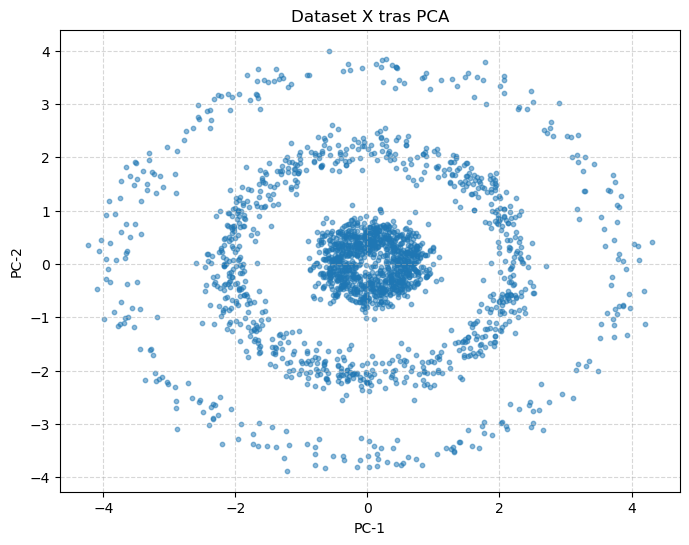

In [46]:
# Creamos la gráfica de X
plt.figure(figsize=(8, 6))                                                                  
plt.scatter(X['PC-1'], X['PC-2'], alpha=0.5, s=10)                                                  
plt.xlabel('PC-1')                                                                                  
plt.ylabel('PC-2')
plt.title('Dataset X tras PCA')                                                                        
plt.grid(True, linestyle='--', alpha=0.5)
plt.show() 

2.2. Genera un histograma de X donde se vean las distancias agrupadas de los puntos al origen
[0,0]

In [47]:
#Calculamos ahora las distancias al punto origen usando a pitágoras
distancias = np.sqrt(X["PC-1"]**2 + X["PC-2"]**2)
distancias

0       0.362260
1       0.383278
2       0.227726
3       0.420214
4       0.375628
          ...   
2045    3.604840
2046    3.628925
2047    3.773367
2048    3.933032
2049    3.644799
Length: 2050, dtype: float64

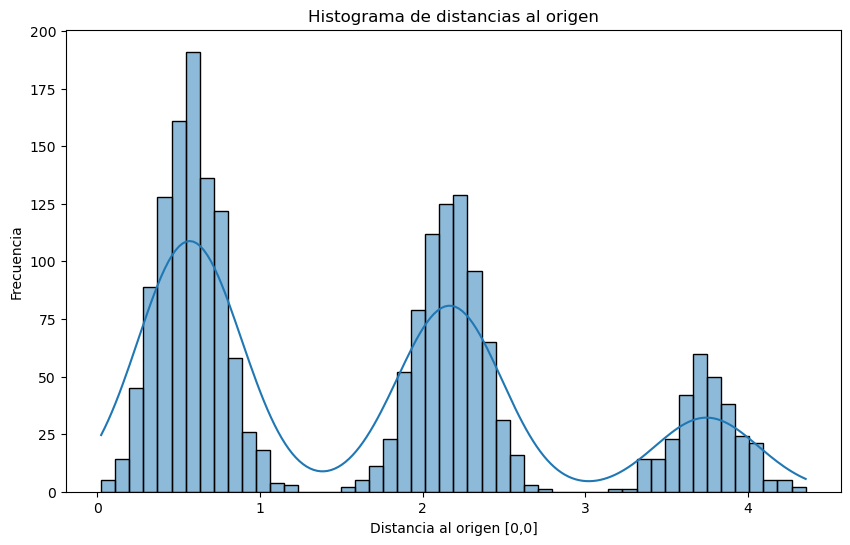

In [ ]:
plt.figure(figsize=(10, 6))                                                                 
sns.histplot(distancias, kde=True, bins=50)
plt.xlabel('Distancia al origen [0,0]')
plt.ylabel('Frecuencia')
plt.title('Histograma de distancias al origen')
plt.show()

2.3. Analiza todos los resultados de las tareas 1 y 2 en un bloque de texto

Una vez que el dataset original ha sido cargado, hemos procedido a estandarizarlos mediante StandardScaler, asegurándonos así de que todas las variables tengan media 0 y desviación típica 1.

Posteriormente hemos aplicado PCA, reduciendo de 4 a 2 dimensiones manteniéndo el 99% (varianza explicada) de la información original. Esto nos permite una visualización en 2D con una similitud casi exacta de lo que hubiese sido en 4D.

En la visualización del dataset (X), podemos ver representados en un plano bidimensional cómo se distribuyen los puntos. Aunque no sepamos a priori cuántos clústers hay, esta primera visualización nos da una idea para enteder la estructura y hacernos una idea.

Por último, el histograma de distancias al origen también nos aporta información útil y que en parte ya ha sido revelada por el gráfico anterior. En el histograma vemos como cada círculo genera un pico en el histograma correspondiente a su radio.

# Tarea 3: Selección de hiperparámetros con DBSCAN

3.1 Haz un estudio del comportamiento de DBSCAN con el dataset X, probando valores de eps de
0.4 a 0.7 (ambos incluidos), con un incremento de 0.01 y valores de min_samples de 3, 4 y 5.
Para cada agrupamiento, calcula el nº de puntos ruido, el porcentaje de puntos ruido y el
índice de Silhouette. Guarda todos los resultados en el DataFrame resultados, ordenado en
primer lugar por eps en orden ascendente y en segundo lugar por min_samples en orden
ascendente. Este DataFrame debe contener por cada fila las columnas eps, min_samples,
clusters, noise, noise_ratio y silhouette. Muestra el DataFrame resultados completo.

In [49]:
eps_valores = np.round(np.arange(0.4, 0.71, 0.01),2)  # 0.4 a 0.7 inclusive       
min_samples_valores = [3, 4, 5]   

resultados = [] #Para guardar resultados

#Iteramos sobre eps y min samples
for eps in eps_valores:
    for min_samples in min_samples_valores:
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        grupos = dbscan.fit_predict(X)
        
        n_clusters = len(set(grupos)) - (1 if -1 in grupos else 0)
        n_noise = np.sum(grupos == -1)
        noise_ratio = n_noise / len(grupos)
        
        grupos_validos = grupos[grupos != -1]
        if 0 in grupos_validos and 1 in grupos_validos:
            silhouette = silhouette_score(X[grupos != -1], grupos_validos)
        else:
            silhouette = np.nan
        
        resultados.append({
            'eps': eps,
            'min_samples': min_samples,
            'clusters': n_clusters,
            'noise': n_noise,
            'noise_ratio': noise_ratio,
            'silhouette': silhouette
        })

resultados= pd.DataFrame(resultados)

#Nos aseguramos de que salga ordenado
resultados = resultados.sort_values(by=['eps', 'min_samples'], ascending=[True, True])
resultados = resultados.reset_index(drop=True)

display(resultados)

,eps,min_samples,clusters,noise,noise_ratio,silhouette
0,0.40,3,6,0,0.0,0.263599
1,0.40,4,7,0,0.0,0.265142
2,0.40,5,8,0,0.0,0.266945
3,0.41,3,6,0,0.0,0.263599
4,0.41,4,7,0,0.0,0.265142
...,...,...,...,...,...,...
88,0.69,4,2,0,0.0,0.428074
89,0.69,5,2,0,0.0,0.428074
90,0.70,3,1,0,0.0,NaN
91,0.70,4,1,0,0.0,NaN


3.2. Selección de las mejores combinaciones: Construye un DataFrame denominado
mejores_candidatos a partir del conjunto de resultados obtenidos, aplicando
secuencialmente los siguientes criterios de filtrado:
- Número de clústers: conservar únicamente aquellas combinaciones que generen
    exactamente 3 clústers (excluyendo el ruido).
- Minimización de ruido: de las combinaciones anteriores, seleccionar solo aquellas
    con el menor valor de noise_ratio.
- Calidad del agrupamiento: de las restantes, conservar únicamente las que presenten
    el mayor valor de silhouette.

Condición de control obligatoria:
- Si tras aplicar el primer criterio no existe ninguna combinación que genere
    exactamente 3 clústers, el programa deberá finalizar inmediatamente lanzando el
    siguiente error: “Con los hiperparámetros probados, no hay combinaciones que
    generen 3 grupos”. Si el programa no finaliza por esta condición, se deberá mostrar
    el DataFrame mejores_candidatos completo como resultado final.

Entre los valores del DataFrame mejores_candidatos elige como resultado final el valor
central.

In [50]:
# Aplicaremos el primer filtro: quedarnos con los que tengan 3 clústers
mejores_candidatos = resultados[resultados['clusters'] == 3]

if len(mejores_candidatos) == 0:
    raise ValueError("Con los hiperparámetros probados, no hay combinaciones que generen 3 grupos")

mejores_candidatos



,eps,min_samples,clusters,noise,noise_ratio,silhouette
27,0.49,3,3,0,0.0,0.213017
28,0.49,4,3,0,0.0,0.213017
29,0.49,5,3,0,0.0,0.213017


In [51]:
# Ahora filtramos por menor noise_ratio
min_noise = mejores_candidatos['noise_ratio'].min()
mejores_candidatos = mejores_candidatos[mejores_candidatos['noise_ratio'] == min_noise]

mejores_candidatos

,eps,min_samples,clusters,noise,noise_ratio,silhouette
27,0.49,3,3,0,0.0,0.213017
28,0.49,4,3,0,0.0,0.213017
29,0.49,5,3,0,0.0,0.213017


In [52]:
# El último filtro, mayor silhouette
max_silhouette = mejores_candidatos['silhouette'].max()
mejores_candidatos = mejores_candidatos[mejores_candidatos['silhouette'] == max_silhouette]
mejores_candidatos = mejores_candidatos.reset_index(drop=True)

mejores_candidatos

,eps,min_samples,clusters,noise,noise_ratio,silhouette
0,0.49,3,3,0,0.0,0.213017
1,0.49,4,3,0,0.0,0.213017
2,0.49,5,3,0,0.0,0.213017


In [53]:
#Ahora seleccionamos el valor central
indice_central = len(mejores_candidatos) // 2
mejor_fila = mejores_candidatos.iloc[indice_central]
eps_final = mejor_fila["eps"]
min_samples_final = int(mejor_fila["min_samples"])
print(f"\nHiperparámetros seleccionados: eps={eps_final}, min_samples={min_samples_final}")


Hiperparámetros seleccionados: eps=0.49, min_samples=4


3.3. En un cuadro de texto comenta los resultados obtenidos y analízalos

En este ejercicio de la práctica nos hemos centrado en la búsqueda de los mejores hiperparámetros probando distintas combinaciones de epsilon y ejemplares mínimos hasta encontrar la que nos permita separar los 3 circulos concéntricos.

El rango de eps probado es de 0.4 a 0.7, ajustandose bien al histograma de distancias al origen y evitando que conecte a dos círculos.

Por otro lado, el min_samples controla la densidad mínima necesaria para formar un grupo.

Los resultados muestran que dependiendo de la combinación, DBSCAN puede identificar distinto números de clústers. Un eps demasiado pequeño puede generar muchos clústers pequeños y puntos de ruido, mientras que un eps grande tiende a fusionar los distintos círculos en un solo clúster.

Al final, tal y como pedía el ejercicio, nos hemos quedados con una combinación que nos permite generar exactamente 3 clústers, con el menor ruido posible y con el mayor índice de silhouette (densidad y separación entre clústers).

Una vez obtenida esa combinación, hemos seleccionado el valor central de todas las posibles.

# Tarea 4: Entrenamiento final y muestra de resultados

4.1. Entrena el dataset X con DBSCAN y los hiperparámetros elegidos previamente. Muestra los
resultados del agrupamiento de forma analítica, indicando:
- Clústers detectados
- Puntos de ruido
- Porcentaje de ruido
- Silhouette (sin ruido)

In [54]:
#Instanciamos con los hiperparametros seleccionados
dbscan_final = DBSCAN(eps=eps_final, min_samples=min_samples_final)
labels_final = dbscan_final.fit_predict(X)

n_clusters_final = len(set(labels_final)) - (1 if -1 in labels_final else 0)
n_noise_final = list(labels_final).count(-1)
noise_ratio_final = n_noise_final / len(X)

mask_final = labels_final != -1
silhouette_final = silhouette_score(X[mask_final], labels_final[mask_final])

print("RESULTADOS DEL AGRUPAMIENTO FINAL")
print("=" * 40)
print(f"Clusteres detectados: {n_clusters_final}")
print(f"Puntos de ruido: {n_noise_final}")
print(f"Porcentaje de ruido: {noise_ratio_final*100:.2f}%")
print(f"Silhouette (sin ruido): {silhouette_final:.6f}")

RESULTADOS DEL AGRUPAMIENTO FINAL
Clusteres detectados: 3
Puntos de ruido: 0
Porcentaje de ruido: 0.00%
Silhouette (sin ruido): 0.213017


4.2. Construye un DataFrame con el nombre datos_agrupados, que contendrá el dataset original
(no el dataset X) con una columna añadida con el grupo al que ha sido asignado cada
elemento. Descarga el DataFrame datos_agrupados al PC local donde se ejecute el
programa, en un fichero csv con el nombre datos_agrupados_tunombre_tuapellido1.csv

In [55]:
#Creamos el dataframe con los datos originales y los labels
datos_agrupados = dataset.copy()
datos_agrupados["cluster"] = labels_final

datos_agrupados

,x1,x2,x3,x4,cluster
0,0.745085,0.157956,0.298389,0.554894,0
1,-0.278093,0.961595,-0.501588,0.442810,0
2,-0.492716,-0.458292,-0.209106,-0.055309,0
3,0.634554,0.867575,0.230347,0.292710,0
4,-0.489600,0.692941,-0.215008,0.631591,0
...,...,...,...,...,...
2045,-0.829776,-6.423646,-2.283739,-6.106001,2
2046,-6.604055,-1.955133,-5.510829,0.121390,2
2047,6.534285,2.593073,5.552991,0.649338,2
2048,-6.129998,3.510286,-4.712059,4.956038,2


In [ ]:
#Descargamos el csv
nombre ="datos_agrupados_david_medina.csv"

from google.colab import files
datos_agrupados.to_csv(nombre, index=False)
files.download(nombre)

4.3. Muestra la gráfica del agrupamiento de X. En el título de la gráfica deben aparecer estas 3
líneas:
- Agrupamiento de X con DBSCAN
- eps=XXX, min_samples=XXX
- Porcentaje de ruido=XXX, Silhouette=XXX
A la vista de la gráfica, redacta tus conclusiones en un bloque de texto

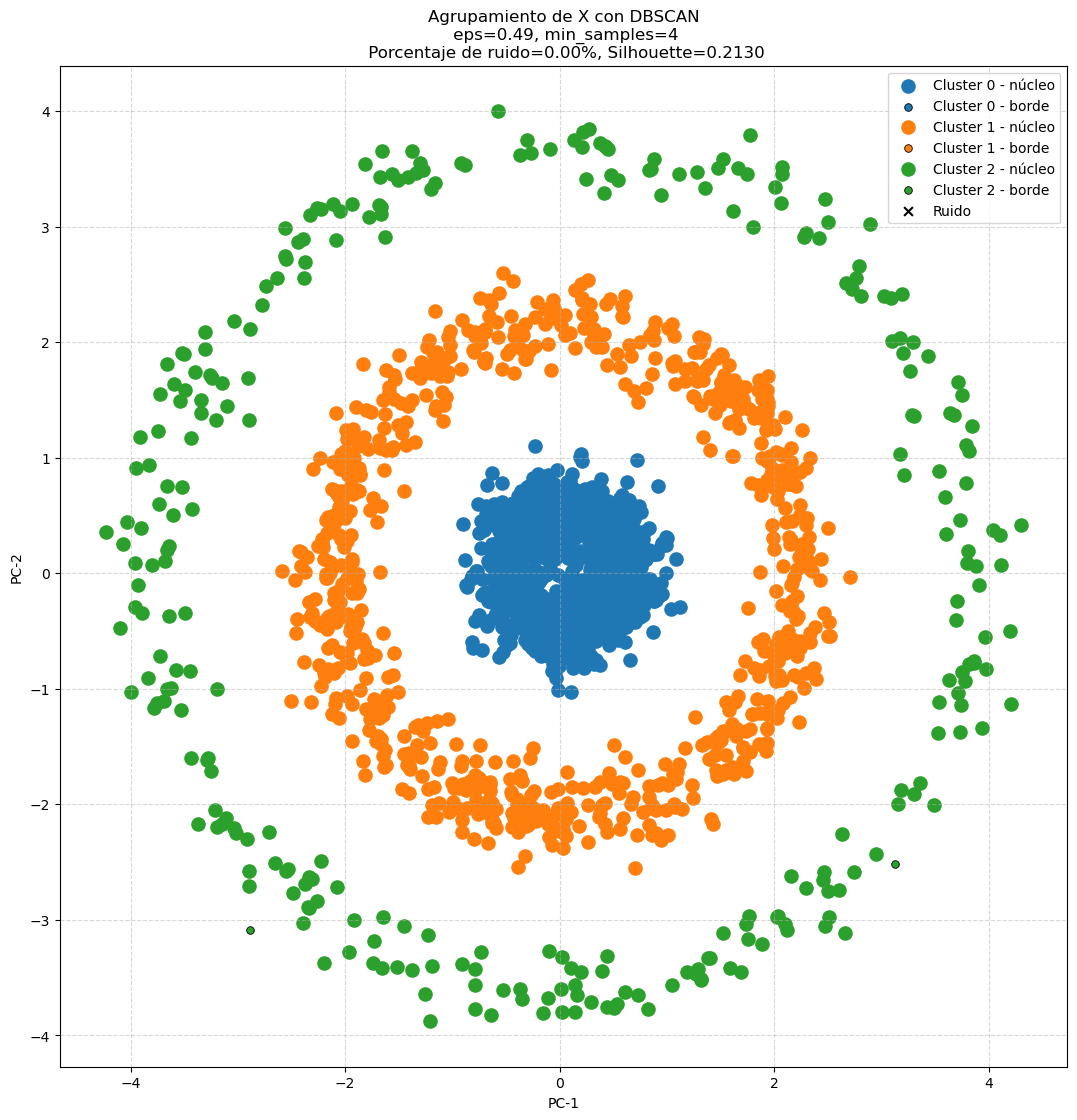

In [57]:
core_samples_mask = np.zeros_like(labels_final, dtype=bool)
core_samples_mask[dbscan_final.core_sample_indices_] = True

cluster_labels = sorted([lab for lab in set(labels_final) if lab != -1])
colors = plt.cm.tab10(np.arange(len(cluster_labels)))

plt.figure(figsize=(13, 13))

for i, label in enumerate(cluster_labels):
    class_mask = labels_final == label
    color = colors[i]
    
    plt.scatter(
        X.loc[class_mask & core_samples_mask, 'PC-1'],
        X.loc[class_mask & core_samples_mask, 'PC-2'],
        s=90,
        c=[color],
        label=f"Cluster {label} - núcleo"
    )
    
    plt.scatter(
        X.loc[class_mask & ~core_samples_mask, 'PC-1'],
        X.loc[class_mask & ~core_samples_mask, 'PC-2'],
        s=30,
        c=[color],
        edgecolors="black",
        linewidths=0.6,
        label=f"Cluster {label} - borde"
    )

noise_mask = labels_final == -1
plt.scatter(
    X.loc[noise_mask, 'PC-1'],
    X.loc[noise_mask, 'PC-2'],
    s=40,
    c="black",
    marker="x",
    label="Ruido"
)

plt.title(f"Agrupamiento de X con DBSCAN\n eps={eps_final}, min_samples={min_samples_final}\n Porcentaje de ruido={noise_ratio_final*100:.2f}%, Silhouette={silhouette_final:.4f}")
plt.xlabel('PC-1')
plt.ylabel('PC-2')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.show()

A la vista de la gráfica, se puede observar que DBSCAN ha logrado separar los 3 círculos concéntricos en 3 clusters distintos. 

En nuestro caso, para la combinación de hiperparámetros seleccionada, no existen puntos de ruido. En el caso de que hubiesen existido, hubiesen sido marcadas con una X.                              

Los puntos núcleo (más grandes) representan las regiones más densas de cada círculo, mientras que los puntos borde (más pequeños con borde negro) completan la estructura del cluster sin ser directamente núcleos del algoritmo. 

El nulo porcentaje de ruido y el alto valor del índice Silhouette indican una buena efectividad del algoritmo para este dataset con círculos concéntricos de densidades heterogéneas. 